Phần bài tập em chia thành 2 phần là Phần 1,2,3 và Phần 4

In [50]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

Đưa vào các thư viện cần thiết cho chương trình 

Phần 1 — Thống kê mô tả & đặc trưng
1. Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng cột.

2. Với mỗi biến số, tính: mean, median, mode, var, std, min, max, Q1, Q3 và IQR.

3. Theo từng nhóm (loài species): dùng groupby tính mean và std của từng biến. Nhận xét nhóm nào khác biệt rõ nhất.

1. Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng cột.

In [51]:
df = sns. load_dataset ("iris") # hoac : from sklearn . datasets import load_iris
print (df. head (5))
D,C=df.shape
print(" Số dòng: ", D)
print(" Số cột: ", C)
print (df. dtypes )

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
 Số dòng:  150
 Số cột:  5
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


2. Với mỗi biến số, tính: mean, median, mode, var, std, min, max, Q1, Q3 và IQR.

In [52]:
def feature(x):
    return pd.Series({
    "Mean": x.mean(),
    "Median": x.median(),
    "Mode": x.mode().iloc[0] if not x.mode().empty else None,
    "Variance": x.var(),
    "Standard Deviation": x.std(),
    "Minimum": x.min(),
    "Maximum": x.max(),
    "Q3": x.quantile(0.75),
    "Q1": x.quantile(0.25),
    "IQR": x.quantile(0.75) - x.quantile(0.25)
})
ketqua=df.select_dtypes(include=['number']).apply(feature).T
print(ketqua)

                  Mean  Median  Mode  Variance  Standard Deviation  Minimum  Maximum   Q3   Q1  IQR
sepal_length  5.843333    5.80   5.0  0.685694            0.828066      4.3      7.9  6.4  5.1  1.3
sepal_width   3.057333    3.00   3.0  0.189979            0.435866      2.0      4.4  3.3  2.8  0.5
petal_length  3.758000    4.35   1.4  3.116278            1.765298      1.0      6.9  5.1  1.6  3.5
petal_width   1.199333    1.30   0.2  0.581006            0.762238      0.1      2.5  1.8  0.3  1.5


3. Theo từng nhóm (loài species): dùng groupby tính mean và std của từng biến. Nhận xét nhóm nào khác biệt rõ nhất.

In [53]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
results= df.groupby("species").agg(['mean','std'])
print(results)

           sepal_length           sepal_width           petal_length           petal_width          
                   mean       std        mean       std         mean       std        mean       std
species                                                                                             
setosa            5.006  0.352490       3.428  0.379064        1.462  0.173664       0.246  0.105386
versicolor        5.936  0.516171       2.770  0.313798        4.260  0.469911       1.326  0.197753
virginica         6.588  0.635880       2.974  0.322497        5.552  0.551895       2.026  0.274650


Dựa vào bảng ta có thể nhận định từ giá trị trung bình của petal length và petal width khác biệt rõ rệt giữa ba nhóm. Đặc biệt, Setosa có chiều dài và chiều rộng cánh hoa nhỏ hơn rất nhiều so với Versicolor và Virginica, nên đây là loài dễ phân biệt nhất. 

Phần 2 — Phân phối xác suất
1. Vẽ histogram + KDE cho từng biến số. Nhận xét hình dạng phân phối: lệch trái/phải, gần phân phối chuẩn, hay nhiều đỉnh?
2. Vẽ boxplot từng biến theo nhóm (species) để so sánh phân phối giữa các loài.
3. Mô phỏng: chọn một biến, sinh mẫu từ phân phối Normal có cùng mean và std bằng np.random.normal; vẽ chồng histogram dữ liệu thực tế với đường PDF lý thuyết. Nhận xét mức độ khớp.

1. Vẽ histogram + KDE cho từng biến số. Nhận xét hình dạng phân phối: lệch trái/phải, gần phân phối chuẩn, hay nhiều đỉnh?

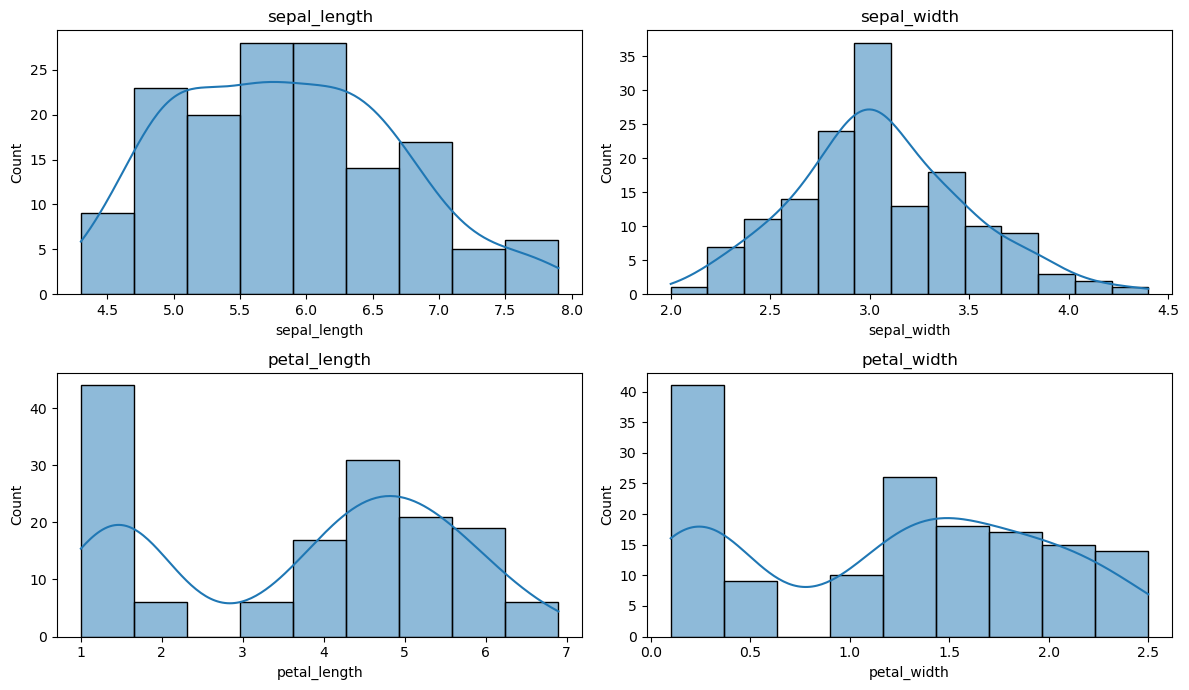

In [54]:
cols = df.select_dtypes(include="number").columns
plt.figure(figsize=(12,7))
for i, col in enumerate(cols,1):
    plt.subplot(2,2,i)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

1. sepal_length
Quan sát thấy: Có một đỉnh chính khoảng 5.5–6.0. Hai phía giảm dần khá đều. Đuôi bên phải hơi dài hơn. Kết luận dữ liệu có phân phối gần phân phối chuẩn, có một đỉnh và hơi lệch phải nhẹ.
2. sepal_width
Quan sát thấy: Có một đỉnh chính khoảng 3. Hai phía giảm cân đối. Kết luận dữ liệu có phân phối gần phân phối chuẩn, có một đỉnh (unimodal) và hơi lệch phải.
3. petal_length
Quan sát thấy: Có hai đỉnh khoảng 1 và khoảng 5. Kết luận có phân phối ko gần phân phối chuẩn. Nguyên nhân là có sự khác biệt rõ rệt giữa setosa và 2 loài còn lại.
4. petal_width
Quan sát thấy: có 2 đỉnh rõ rệt khoảng 0.3 và 1.5. Tương tự như petal_length có phân phối ko gần phân phối chuẩn.

2. Vẽ boxplot từng biến theo nhóm (species) để so sánh phân phối giữa các loài.

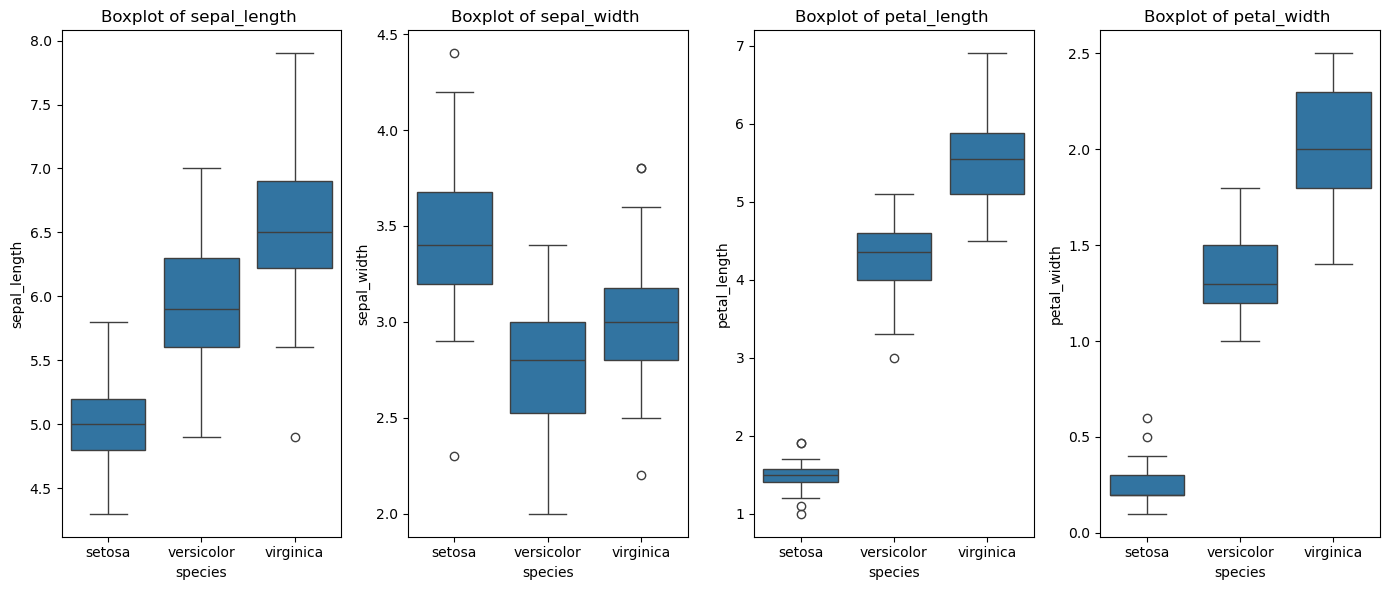

In [55]:
plt.figure(figsize=(14,6))
for i,sp in enumerate(cols,1):
    plt.subplot(1,4,i)
    sns.boxplot(x="species", y=sp, data=df)
    plt.title(f"Boxplot of {sp} ")
plt.tight_layout() 
plt.show()

3. Mô phỏng: chọn một biến, sinh mẫu từ phân phối Normal có cùng mean và std bằng np.random.normal; vẽ chồng histogram dữ liệu thực tế với đường PDF lý thuyết. Nhận xét mức độ khớp.

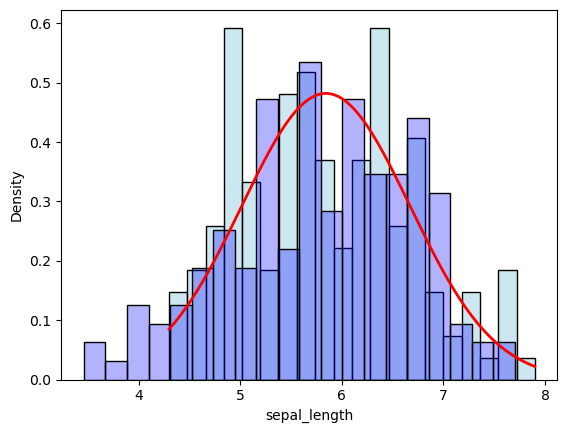

In [56]:
x=df["sepal_length"]
sample= np.random.normal(x.mean(), x.std(), len(x))
sns.histplot(x, bins=20, stat="density", color= "lightblue",alpha=0.6 )
sns.histplot(sample, stat="density", bins=20, alpha=0.3,color="blue")
xx = np.linspace(x.min(), x.max(), 200)
plt.plot(xx, norm.pdf(xx, x.mean(), x.std()), color="red", linewidth=2)
plt.show()

Quan sát biểu đồ cho thấy histogram của dữ liệu thực tế và mẫu được mô phỏng từ phân phối chuẩn có hình dạng khá giống nhau. Đường cong PDF cũng bám khá sát phần dữ liệu tập trung ở giữa, cho thấy phân phối chuẩn mô tả tương đối tốt biến sepal_length. Tuy nhiên, ở hai đầu phân phối vẫn có một số khác biệt do dữ liệu thực tế không hoàn toàn tuân theo phân phối chuẩn. Tóm lại, có thể nhận định sepal_length gần với phân phối chuẩn, nhưng vẫn tồn tại một số sai lệch nhỏ so với mô hình lý thuyết

Phần 3 — Phân tích đa biến & tương quan
1. Tính ma trận hiệp phương sai (covariance) và tương quan (correlation) giữa các biến số.
2. Vẽ heatmap tương quan; nhận xét cặp biến tương quan mạnh nhất. Có dấu hiệu đa cộng tuyến không?
3. Vẽ pairplot (hoặc scatter theo cặp), tô màu theo species; nhận xét quan hệ giữa các biến.

1. Tính ma trận hiệp phương sai (covariance) và tương quan (correlation) giữa các biến số.

In [57]:
num=df.select_dtypes("number")
cov_matrix = num.cov()
print("Cov_matrix: \n", cov_matrix)
corr_matrix =num.corr()
print("\n Corr_matrix \n", corr_matrix)

Cov_matrix: 
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

 Corr_matrix 
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


2. Vẽ heatmap tương quan; nhận xét cặp biến tương quan mạnh nhất. Có dấu hiệu đa cộng tuyến không?

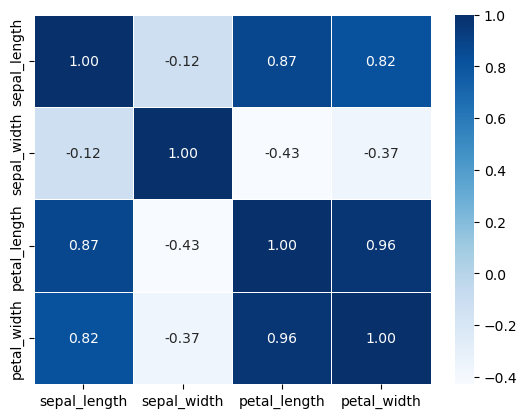

In [58]:
sns.heatmap(corr_matrix,
            annot=True,
            cmap="Blues",
            fmt=".2f",
            linewidths= 0.5,
            cbar= True,
            linecolor="white"
            )
plt.show()

Cặp 2 biến petal_length và pental_width có tương quan dương mạnh nhất: 0.96. Độ dài cánh hoa càng lớn thì độ rộng cánh hoa cũng càng lớn nên nếu đưa cả 2 biến này vào mô hình với vai trò là 2 biến độc lập sẽ xảy ra cộng đa tuyến.

3. Vẽ pairplot (hoặc scatter theo cặp), tô màu theo species; nhận xét quan hệ giữa các biến.

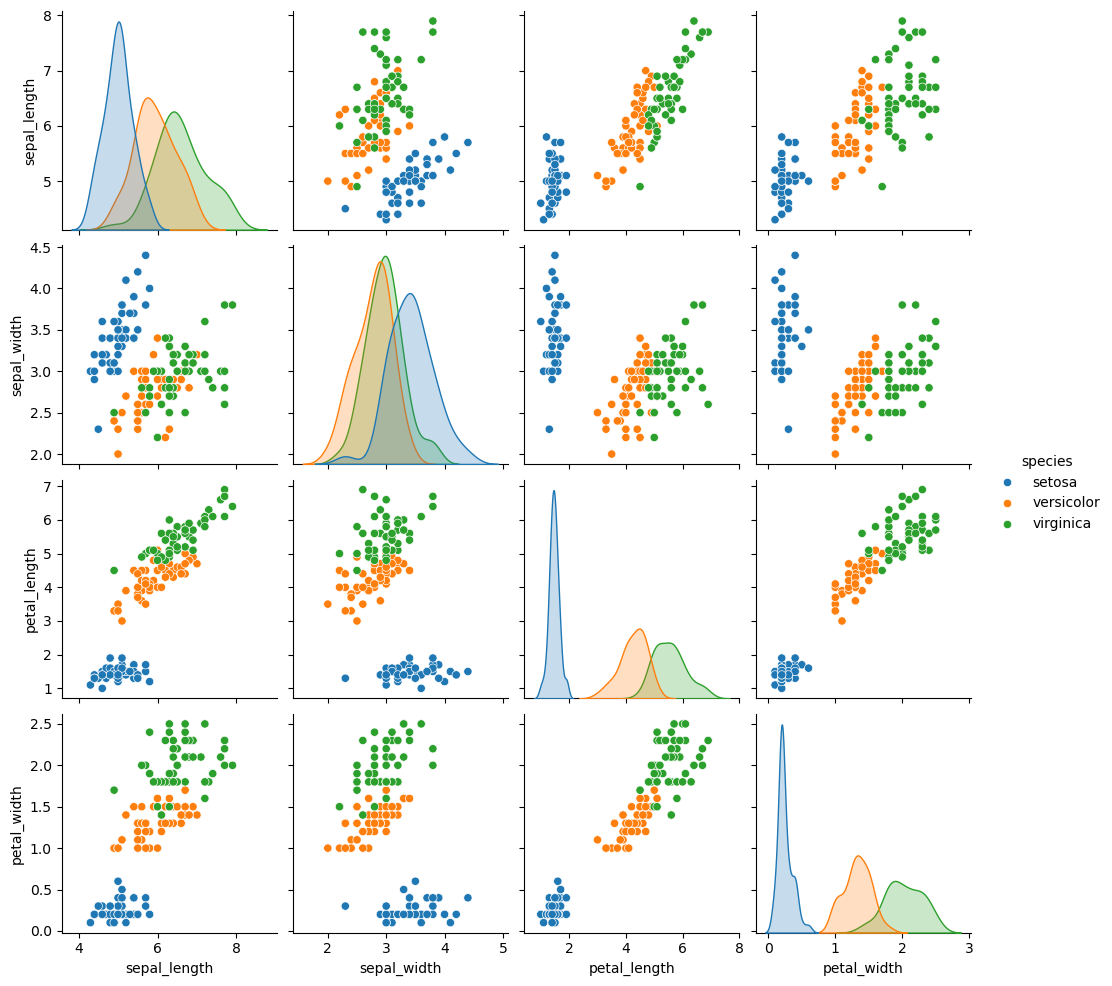

In [59]:
sns.pairplot(df,hue="species")
plt.show()

Pairplot cho thấy petal_length và petal_width có tương quan dương rất mạnh. Sepal_length cũng tương quan dương với hai biến này, trong khi sepal_width có tương quan yếu hơn. Về phân loại, Setosa được tách biệt rõ ràng, còn Versicolor và Virginica có một phần chồng lấn. Điều này cho thấy petal_length và petal_width là hai biến phân biệt các loài tốt nhất.

Phần 4 — Xác suất & Định lý Bayes
Bài toán chẩn đoán. Một bệnh có tỉ lệ mắc trong dân số là P(B) = 0.01. Một xét
nghiệm có:
• Độ nhạy (true positive): P(+ | B) = 0.99.
• Dương tính giả (false positive): P(+ | ¬B) = 0.05.
1. Viết code tính xác suất hậu nghiệm P(B | +) bằng định lý Bayes và in kết quả.
2. Khảo sát: vẽ đồ thị P(B | +) khi tỉ lệ mắc bệnh P(B) thay đổi từ 0.001 đến 0.2. Giải thích vì sao khi bệnh hiếm, kết quả lại "phản trực giác".
3. (Tùy chọn, bonus) Xây dựng một bộ lọc spam đơn giản theo Naive Bayes trên vài
từ khóa cho sẵn; tính P(spam | email) cho 2–3 email ví dụ.

 1. Viết code tính xác suất hậu nghiệm P(B | +) bằng định lý Bayes và in kết quả.

In [60]:
P_B=0.01
P_notB=1-0.01
P_pos_givenB= 0.99
P_pos_givnNB= 0.05
P_pos= P_pos_givenB*P_B+ P_pos_givnNB * P_notB
P_B_given_pos= P_pos_givenB * P_B / P_pos
print(round(P_B_given_pos,4))

0.1667


2. Khảo sát: vẽ đồ thị P(B | +) khi tỉ lệ mắc bệnh P(B) thay đổi từ 0.001 đến 0.2. Giải thích vì sao khi bệnh hiếm, kết quả lại "phản trực giác".

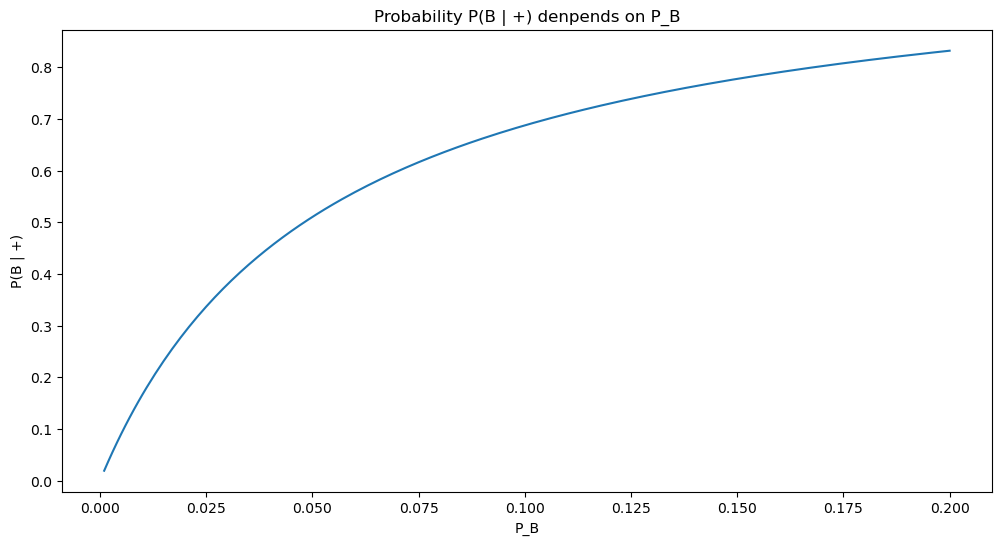

In [61]:
import numpy as np
import matplotlib.pyplot as plt 
x=np.linspace(0.001,0.2,200)
y=[]
for i in x:
    P_pos= P_pos_givenB*i+ P_pos_givnNB * (1-i)
    P_B_given_pos= P_pos_givenB * i / P_pos
    y.append(P_B_given_pos)
plt.figure(figsize=(12,6))
plt.plot(x,y)
plt.xlabel("P_B")
plt.ylabel("P(B | +)")
plt.title("Probability P(B | +) denpends on P_B")
plt.show()

Đồ thị cho thấy P(B∣+) tăng khi tỷ lệ mắc bệnh P(B) tăng. Khi bệnh rất hiếm, dù xét nghiệm có độ chính xác cao, xác suất thực sự mắc bệnh sau khi có kết quả dương tính vẫn thấp do số ca dương tính giả từ nhóm người khỏe lớn hơn số ca mắc bệnh. Vì vậy, khi bệnh càng phổ biến thì kết quả dương tính càng đáng tin cậy.